In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

In [2]:
# Load CSV file
df = pd.read_csv("Loan Eligibility Prediction.csv")

# Preview
print("Shape:", df.shape)
display(df.head())
print(df.info())

Shape: (614, 13)


,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    str    
 2   Married             614 non-null    str    
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    str    
 5   Self_Employed       614 non-null    str    
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    str    
 12  Loan_Status         614 non-null    str    
dtypes: float64(1), int64(6), str(6)
memory usage: 77.8 KB
None


In [3]:
# Drop ID column if present
for col in ["Loan_ID", "Customer_ID"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [5]:
# Impute numeric columns with median
if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy="median")
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute categorical columns with most frequent
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
# Build a text feature from categorical columns
# Convert each row's categorical data into one sentence
text_cols = [col for col in categorical_cols]

df["profile_text"] = df[text_cols].astype(str).agg(" ".join, axis=1)

display(df[["profile_text"]].head())

,profile_text
0,Female No Graduate No Urban N
1,Male Yes Graduate No Urban Y
2,Male No Not Graduate No Semiurban Y
3,Male Yes Graduate Yes Semiurban Y
4,Male Yes Graduate No Semiurban Y


In [7]:
tfidf = TfidfVectorizer(stop_words="english")
X_tfidf = tfidf.fit_transform(df["profile_text"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (614, 7)


In [8]:
# Use only numeric columns for KMeans from the original dataset
X_num = df[numeric_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

print("Scaled numeric feature shape:", X_scaled.shape)

Scaled numeric feature shape: (614, 6)


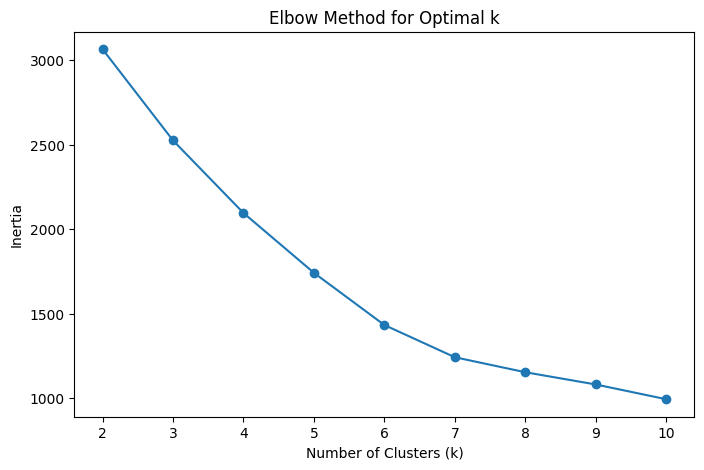

In [9]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [10]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.3920
k=3, Silhouette Score=0.4060
k=4, Silhouette Score=0.4353
k=5, Silhouette Score=0.4450
k=6, Silhouette Score=0.3757
k=7, Silhouette Score=0.3830
k=8, Silhouette Score=0.3093
k=9, Silhouette Score=0.3261
k=10, Silhouette Score=0.3287


In [11]:
best_k = 3  # Change this after inspecting elbow/silhouette results

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

display(df.head())
print(df["Cluster"].value_counts())

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,profile_text,Cluster
0,Female,No,0.0,Graduate,No,2378.0,0.0,9.0,360.0,1.0,Urban,N,Female No Graduate No Urban N,0
1,Male,Yes,2.0,Graduate,No,1299.0,1086.0,17.0,120.0,1.0,Urban,Y,Male Yes Graduate No Urban Y,0
2,Male,No,0.0,Not Graduate,No,3620.0,0.0,25.0,120.0,1.0,Semiurban,Y,Male No Not Graduate No Semiurban Y,0
3,Male,Yes,0.0,Graduate,Yes,3459.0,0.0,25.0,120.0,1.0,Semiurban,Y,Male Yes Graduate Yes Semiurban Y,0
4,Male,Yes,1.0,Graduate,No,5468.0,1032.0,26.0,360.0,1.0,Semiurban,Y,Male Yes Graduate No Semiurban Y,0


Cluster
0    487
2     88
1     39
Name: count, dtype: int64


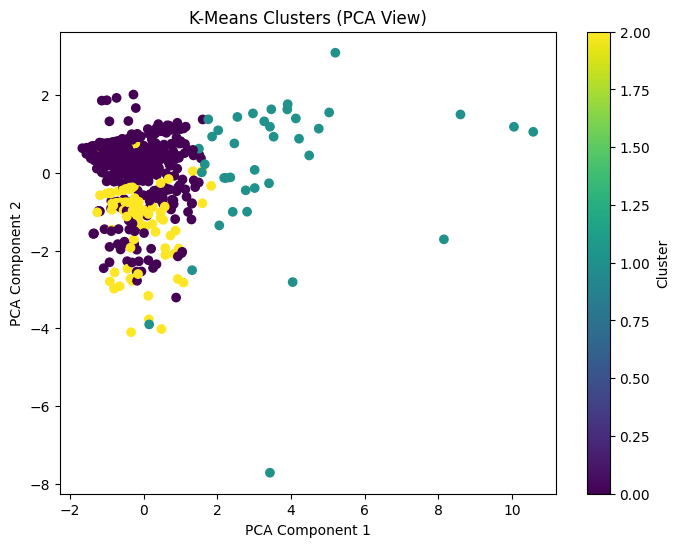

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (PCA View)")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [13]:
cluster_summary = df.groupby("Cluster")[numeric_cols].mean()
display(cluster_summary)

# If loan status exists, inspect relationship with cluster
if "Loan_Status" in df.columns:
    print(pd.crosstab(df["Cluster"], df["Loan_Status"]))

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
Cluster,,,,,,
0,0.776181,4521.248460,1411.564517,126.154004,339.893224,1.000000
1,1.743590,18820.641026,4650.487179,376.128205,346.153846,0.897436
2,0.909091,4339.443182,1439.136364,126.090909,330.136364,0.000000


Loan_Status   N    Y
Cluster             
0            98  389
1            15   24
2            79    9


In [14]:
feature_names = np.array(tfidf.get_feature_names_out())

# Convert sparse matrix to array only if dataset is small enough
X_tfidf_dense = X_tfidf.toarray()

for cluster_id in sorted(df["Cluster"].unique()):
    cluster_rows = df["Cluster"] == cluster_id
    mean_tfidf = X_tfidf_dense[cluster_rows].mean(axis=0)
    top_indices = mean_tfidf.argsort()[::-1][:10]
    
    print(f"\nTop words for Cluster {cluster_id}:")
    print(", ".join(feature_names[top_indices]))


Top words for Cluster 0:
male, yes, graduate, semiurban, urban, rural, female

Top words for Cluster 1:
yes, male, graduate, rural, urban, semiurban, female

Top words for Cluster 2:
graduate, male, yes, urban, semiurban, rural, female


In [15]:
df.to_csv("loan_clustered_output.csv", index=False)
print("Saved as loan_clustered_output.csv")

Saved as loan_clustered_output.csv
